<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [63]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [64]:
import os
import platform
import zipfile # Usamos la librería nativa de Python

if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    
    # Descomprimimos usando Python en lugar de comandos de consola
    print("Descomprimiendo archivo...")
    with zipfile.ZipFile('songs_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('./')
    print("¡Descarga y extracción completas!")
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [65]:
# Posibles bandas
os.listdir("./songs_dataset/")

['adele.txt',
 'al-green.txt',
 'alicia-keys.txt',
 'amy-winehouse.txt',
 'beatles.txt',
 'bieber.txt',
 'bjork.txt',
 'blink-182.txt',
 'bob-dylan.txt',
 'bob-marley.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'bruno-mars.txt',
 'cake.txt',
 'dickinson.txt',
 'disney.txt',
 'dj-khaled.txt',
 'dolly-parton.txt',
 'dr-seuss.txt',
 'drake.txt',
 'eminem.txt',
 'janisjoplin.txt',
 'jimi-hendrix.txt',
 'johnny-cash.txt',
 'joni-mitchell.txt',
 'kanye-west.txt',
 'kanye.txt',
 'Kanye_West.txt',
 'lady-gaga.txt',
 'leonard-cohen.txt',
 'lil-wayne.txt',
 'Lil_Wayne.txt',
 'lin-manuel-miranda.txt',
 'lorde.txt',
 'ludacris.txt',
 'michael-jackson.txt',
 'missy-elliott.txt',
 'nickelback.txt',
 'nicki-minaj.txt',
 'nirvana.txt',
 'notorious-big.txt',
 'notorious_big.txt',
 'nursery_rhymes.txt',
 'patti-smith.txt',
 'paul-simon.txt',
 'prince.txt',
 'r-kelly.txt',
 'radiohead.txt',
 'rihanna.txt']

In [66]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

C:\Users\ROA22468\AppData\Local\Temp\ipykernel_13656\3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [67]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [68]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [69]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [70]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [71]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [72]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [73]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [74]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [75]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.2421875
Loss after epoch 1: 65966.5390625
Loss after epoch 2: 65934.96875
Loss after epoch 3: 65718.46875
Loss after epoch 4: 63875.09375
Loss after epoch 5: 64160.96875
Loss after epoch 6: 64080.34375
Loss after epoch 7: 64815.0
Loss after epoch 8: 62632.5625
Loss after epoch 9: 60452.6875
Loss after epoch 10: 59839.6875
Loss after epoch 11: 58884.1875
Loss after epoch 12: 57715.9375
Loss after epoch 13: 56494.0
Loss after epoch 14: 55817.4375
Loss after epoch 15: 55843.0
Loss after epoch 16: 51722.5
Loss after epoch 17: 49858.0
Loss after epoch 18: 49592.125
Loss after epoch 19: 48960.375


(156986, 287740)

### 4 - Ensayar

In [76]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954252004623413),
 ('sleep', 0.8665634989738464),
 ('help', 0.8439401388168335),
 ('cry', 0.8351268172264099),
 ('not', 0.8309596180915833),
 ('try', 0.8276923298835754),
 ('peace', 0.8144838213920593),
 ('little', 0.8140546679496765),
 ('twist', 0.8123897314071655),
 ('seems', 0.8079550266265869)]

In [77]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22873109579086304),
 ('four', -0.2330222725868225),
 ('five', -0.23746444284915924),
 ('six', -0.2378462553024292),
 ('bang', -0.2483222931623459),
 ('our', -0.2553924024105072),
 ('day', -0.26898154616355896),
 ('going', -0.2692105174064636),
 ('here', -0.26990073919296265),
 ('three', -0.28389662504196167)]

In [78]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.981372058391571),
 ('three', 0.9745771884918213),
 ('six', 0.9710807204246521),
 ('seven', 0.9584371447563171),
 ('two', 0.9517236351966858),
 ('sixty', 0.8990399241447449),
 ('one', 0.795117199420929),
 ('crying', 0.7946274876594543),
 ('us', 0.7740070819854736),
 ("i'm", 0.7508386969566345)]

In [79]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434005618095398),
 ('buy', 0.939699113368988),
 ('much', 0.9033195972442627),
 ('just', 0.850908637046814),
 ('hide', 0.8355352282524109)]

In [80]:
# Ensayar con una palabra que no está en el vocabulario:
#w2v_model.wv.most_similar(negative=["diedaa"])

In [81]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138413  0.05881019 -0.06370354  0.02445617 -0.20152482 -0.18611853
 -0.15284552  0.45486635 -0.04217679  0.03535806  0.13657518 -0.18519785
 -0.18126503  0.22149378 -0.30380824 -0.23969936  0.07094827 -0.0567887
 -0.05165625 -0.2384332  -0.08529592  0.19564067 -0.07679196  0.03796551
  0.0751621  -0.0482575   0.07379384  0.10396665  0.00737955 -0.22764955
 -0.04567023  0.12936655  0.27785373  0.19387273 -0.13510206  0.20857345
  0.40917116 -0.00386532 -0.10631495 -0.09056864  0.02401222 -0.08005036
  0.13399509  0.08833685 -0.01894409  0.08592524 -0.1590568   0.10259779
  0.14459649 -0.12092511 -0.27919346 -0.04061023  0.11382007  0.31366137
 -0.0740839   0.139766    0.22791134  0.13208385 -0.0181147   0.09772249
  0.09249445 -0.14871854 -0.163485   -0.1320215  -0.09834237  0.02714372
  0.16531056  0.26052314 -0.03259229 -0.02894631  0.11621047 -0.06974225
  0.09562858 -0.15276162  0.22070931  0.15996651  0.15890568 -0.04711937
 -0.12555729 -0.03992885 -0.10795498  0.01878585  0.

In [82]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 1.0),
 ('babe', 0.9085155129432678),
 ('someone', 0.8886153101921082),
 ('need', 0.8827986717224121),
 ('nothing', 0.8740268349647522),
 ("didn't", 0.8638384938240051),
 ("there's", 0.8526657223701477),
 ('you', 0.8456713557243347),
 ('feed', 0.8445047736167908),
 ('somebody', 0.8362796306610107)]

In [83]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085155129432678),
 ('someone', 0.8886153101921082),
 ('need', 0.8827986717224121),
 ('nothing', 0.8740268349647522),
 ("didn't", 0.8638384938240051),
 ("there's", 0.8526657223701477),
 ('you', 0.8456713557243347),
 ('feed', 0.8445047736167908),
 ('somebody', 0.8362796306610107),
 ('buy', 0.8351762294769287)]

### 5 - Visualizar agrupación de vectores

In [84]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [85]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show()

In [86]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show() # esto para plotly en colab

In [87]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

1- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)

2- Elegir términos de interés y buscar términos más similares y menos similares.

3- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.

4- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

### 1 
Para este corpus utilicé un libro muy clásico argentino descargado en formato .txt. (El Martin Fierro) El procesamiento consiste en leer el archivo, separar el texto en oraciones (por cada salto de línea o punto) y luego utilizar expresiones regulares para limpiar la puntuación, pasar todo a minúsculas y tokenizar las palabras. Finalmente, con esos tokens entrenamos nuestro propio modelo Word2Vec.

In [89]:
import urllib.request
import re
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

# 1. Descargamos 
url = "https://www.gutenberg.org/cache/epub/14765/pg14765.txt"
response = urllib.request.urlopen(url)
raw_text = response.read().decode('utf-8')

# 2. Preprocesamiento: separar por puntos para tener oraciones
oraciones_crudas = raw_text.split('.')

sentence_tokens_custom = []
for oracion in oraciones_crudas:
    # Pasamos a minúscula y extraemos palabras limpias
    tokens = re.findall(r'\b\w+\b', oracion.lower())
    # Filtramos oraciones muy cortas para evitar meter ruido al modelo
    if len(tokens) > 2: 
        sentence_tokens_custom.append(tokens)

print(f"Cantidad de oraciones en el corpus: {len(sentence_tokens_custom)}")

# 3. Entrenamos el modelo Word2Vec
class callback(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print(f'Loss after epoch {self.epoch}: {loss}')
        else:
            print(f'Loss after epoch {self.epoch}: {loss - self.loss_previous_step}')
        self.epoch += 1
        self.loss_previous_step = loss


w2v_custom = Word2Vec(min_count=5, window=5, vector_size=300, negative=20, workers=1, sg=1, seed=1234)
w2v_custom.build_vocab(sentence_tokens_custom)

print(f"Palabras distintas en el vocabulario: {len(w2v_custom.wv.index_to_key)}")

# Entrenamos
w2v_custom.train(sentence_tokens_custom,
                 total_examples=w2v_custom.corpus_count,
                 epochs=20,
                 compute_loss=True,
                 callbacks=[callback()])

Cantidad de oraciones en el corpus: 562
Palabras distintas en el vocabulario: 404
Loss after epoch 0: 152563.234375
Loss after epoch 1: 107222.671875
Loss after epoch 2: 110262.34375
Loss after epoch 3: 107705.125
Loss after epoch 4: 105426.125
Loss after epoch 5: 101357.125
Loss after epoch 6: 96565.5625
Loss after epoch 7: 98168.625
Loss after epoch 8: 98768.8125
Loss after epoch 9: 98208.375
Loss after epoch 10: 95433.25
Loss after epoch 11: 95576.25
Loss after epoch 12: 96638.875
Loss after epoch 13: 95777.5
Loss after epoch 14: 96670.5
Loss after epoch 15: 98565.0
Loss after epoch 16: 98885.125
Loss after epoch 17: 98577.625
Loss after epoch 18: 99419.875
Loss after epoch 19: 96542.375


(119841, 311100)

El entrenamiento del modelo sobre el corpus del *Martín Fierro* resultó estable, observándose una disminución consistente de la función de pérdida a lo largo de las épocas. El tamaño del vocabulario (404 palabras) es esperable para un texto de esta extensión.

### 2 
Con el modelo ya entrenado, nos metemos a explorar las relaciones semánticas aprendidas. Para eso definimos términos clave como "gaucho", "hombre" y "tierra" para observar con qué otras palabras se asocian fuertemente y cuáles se alejan en el espacio vectorial.

In [90]:
palabras_interes = ["gaucho", "hombre", "tierra"]

for palabra in palabras_interes:
    
        print(f"--- Análisis de: '{palabra.upper()}' ---")
        
        print("MÁS similares:")
        similares = w2v_custom.wv.most_similar(positive=[palabra], topn=5)
        for sim, puntaje in similares:
            print(f" {sim} ({puntaje:.3f})")
            
        print("MENOS similares:")
        opuestas = w2v_custom.wv.most_similar(negative=[palabra], topn=5)
        for op, puntaje in opuestas:
            print(f" {op} ({puntaje:.3f})")
        print("\n")
    

--- Análisis de: 'GAUCHO' ---
MÁS similares:
 tiene (0.902)
 porque (0.902)
 es (0.900)
 ha (0.885)
 ser (0.884)
MENOS similares:
 states (-0.378)
 united (-0.384)
 not (-0.385)
 do (-0.397)
 we (-0.398)


--- Análisis de: 'HOMBRE' ---
MÁS similares:
 aquel (0.988)
 mas (0.987)
 gente (0.986)
 cuanto (0.985)
 sólo (0.985)
MENOS similares:
 electronic (-0.267)
 work (-0.268)
 works (-0.272)
 any (-0.272)
 to (-0.272)


--- Análisis de: 'TIERRA' ---
MÁS similares:
 algún (0.993)
 tener (0.993)
 sobre (0.993)
 dar (0.992)
 poncho (0.992)
MENOS similares:
 electronic (-0.344)
 work (-0.346)
 works (-0.353)
 any (-0.353)
 or (-0.353)




Al buscar las palabras más similares a "gaucho", "hombre" y "tierra", vemos asociaciones con verbos y pronombres muy frecuentes en el texto. Sin embargo, lo más destacable ocurre en las palabras menos similares, donde aparecen términos en inglés ("states", "united", "work"). 
Esto se debe a que el archivo de Project Gutenberg incluye una extensa licencia legal en inglés al inicio y al final. Como el modelo Word2Vec aprende por contexto, al notar que esas palabras en inglés nunca se mezclan con los versos en español, las aleja hacia el extremo opuesto del espacio vectorial. Esto demuestra cómo el modelo logra separar semánticamente dos idiomas y formatos de texto distintos sin supervisión.

Es muy interesante cómo el algoritmo aísla las palabras en inglés guiándose solo por el contexto. Por eso, prefiero dejar este 'ruido' dentro del corpus para ver dónde terminan cayendo estos términos en la visualización final.

### 3 
Para poder interpretar visualmente las relaciones que aprendió el modelo, reducimos los 300 componentes de los embeddings a solo 2 dimensiones utilizando t-SNE. Limitamos el gráfico a 200 palabras (MAX_WORDS) para que la visualización sea legible y podamos identificar posibles clústeres.

In [92]:
from sklearn.manifold import TSNE
import numpy as np
import plotly.express as px

def reduce_dimensions(model, num_dimensions=2):
    
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)
    tsne = TSNE(n_components=num_dimensions, random_state=42)
    vectors_reduced = tsne.fit_transform(vectors)

    return vectors_reduced, labels

vecs, labels = reduce_dimensions(w2v_custom)

MAX_WORDS = 200
fig = px.scatter(x=vecs[:MAX_WORDS, 0], y=vecs[:MAX_WORDS, 1], text=labels[:MAX_WORDS])
fig.update_traces(textposition='top center')
fig.update_layout(title="Word2Vec: Proyección t-SNE a 2D (Martín Fierro)", height=600)
fig.show() # Si estás en Jupyter/VS Code local. En colab usar: fig.show(renderer="colab")

### 4 - 
Al analizar la proyección de los embeddings en 2D, se observan agrupaciones semánticas claras que el modelo aprendió de forma no supervisada:

1. Clúster por contexto/idioma: 
   La característica más evidente del gráfico es la división en dos grandes bloques separados por un vacío enorme en el eje X. A la derecha quedó recluido todo el vocabulario en inglés perteneciente a la licencia de Project Gutenberg. Al no interactuar jamás en la misma oración con los versos del poema, el modelo aisló este contexto legal completamente del resto de la obra.
   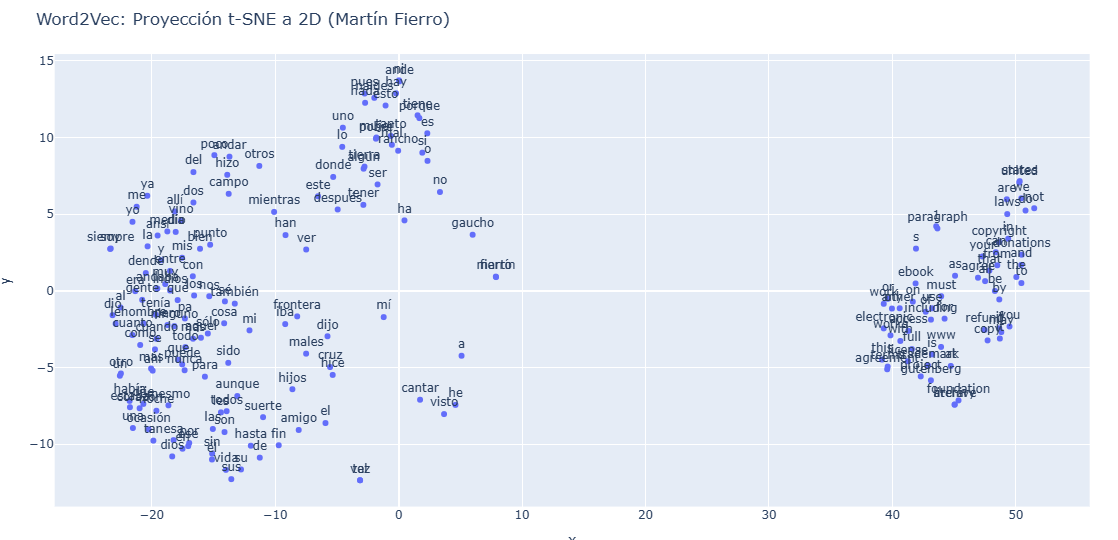

2. Micro-clústeres temáticos (El mundo gauchesco a la izquierda):
   Dentro del bloque en español, se pueden identificar pequeños grupos de palabras afines:
   * **Entorno y pertenencias (Centro-arriba):** Cerca de las coordenadas (X: 0, Y: 10) se agrupan términos del entorno físico como "campo", "tierra", "ranchos" y "pasto", ligados a verbos de estado y posesión ("tener", "tiene", "es", "ser"). (ver imagen 1 debajo)
   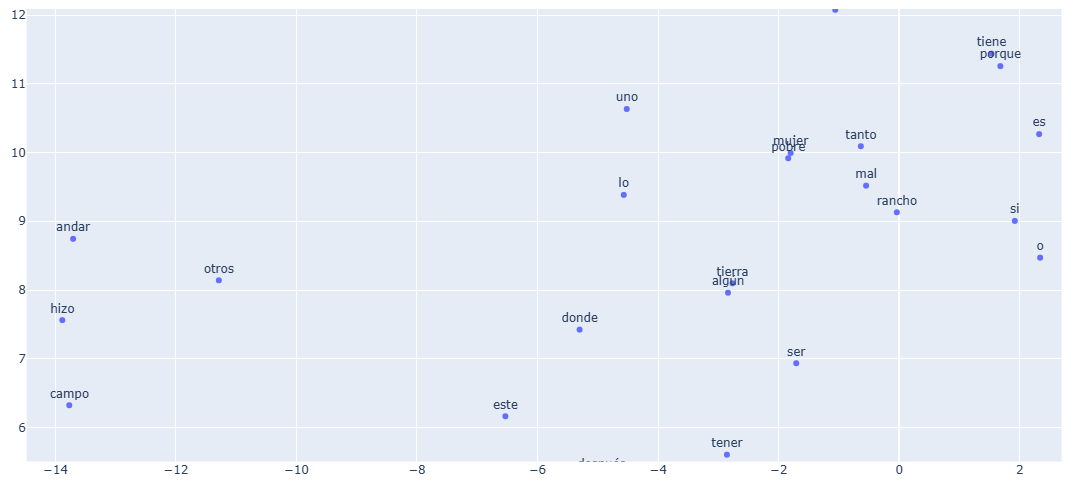
   
   * **Vínculos y pesares (Abajo-centro):** Alrededor de (X: -10, Y: -7) se formó un clúster más existencial. Palabras como "amigo", "hijos", "suerte", "males" y "vida" aparecen muy cercanas, capturando la temática central de los lamentos y las relaciones personales del Martín Fierro.
   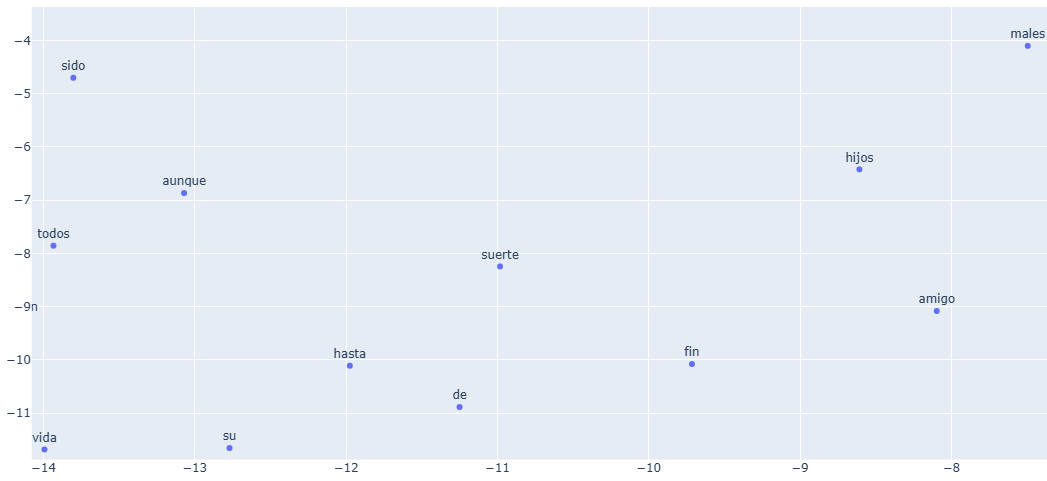

   * **Narrativa y viaje (Centro):** Palabras clave de la historia como "frontera" y "cruz" aparecen junto a verbos de acción y relato como "iba", "dijo" y "hice".
   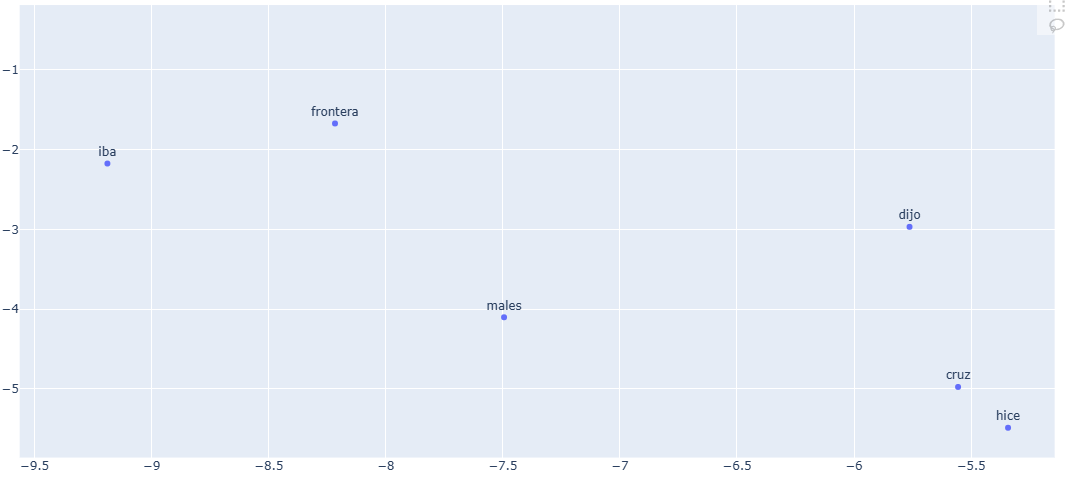

**Conclusión:**
Word2Vec logró capturar exitosamente las relaciones semánticas del texto. Pudo separar dos idiomas y formatos de texto opuestos y también logró agrupar espacialmente los conceptos rurales, los pesares más sentimentales del gaucho y la estructura narrativa de la obra.